# Beer Review Analysis

This project analyzes beer review data to understand patterns in beer ratings, reviewer behavior, and beer style performance.  
The dataset contains information about beers, breweries, reviewers, and ratings such as aroma, taste, appearance, palate, and overall score.

The goal is to clean and merge the datasets, handle missing values, and analyze which beer styles perform the best and worst based on reviewer ratings.

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

## Loading the Datasets

Three datasets are loaded for the analysis:

• beer_info – contains information about beers such as style, brewery, and alcohol content  
• beer_reviews – contains overall ratings given by reviewers  
• review_details – contains detailed rating attributes such as aroma, taste, appearance, and palate

These datasets will later be merged to create a complete dataset for analysis.

In [120]:
beer_info = pd.read_csv("beer_info.csv")
beer_reviews = pd.read_csv("beer_reviews.csv")
review_details = pd.read_csv("review_details.csv")

In [121]:
beer_info.shape

(242921, 4)

In [122]:
beer_reviews.shape

(1654502, 4)

In [123]:
review_details.shape

(1654502, 5)

In [124]:
beer_info.describe()

,beer_abv
count,204526.000000
mean,6.558847
std,2.197321
min,0.010000
25%,5.000000
50%,6.000000
75%,7.800000
max,57.700000


### Checking Missing Values

Missing values are identified in order to determine which columns require cleaning.

Insight:  
Some attributes such as brewery name and beer ABV contain missing values that must be handled before analysis.

In [125]:
beer_info.isna().sum()

beer_name           0
brewery_name       12
beer_style          0
beer_abv        38395
dtype: int64

### Merging Beer Information with Reviews

The beer reviews dataset is merged with beer information using beer name as the key.

Insight:  
This merge connects reviewer ratings with beer attributes such as brewery, style, and alcohol content.

In [126]:
merged = pd.merge(beer_reviews, beer_info, on = "beer_name", how = "left")

### Missing Values After Merge

After merging the datasets, missing values are checked again.

Insight:  
Some reviews do not have corresponding beer information, which leads to missing brewery or style values.


In [127]:
merged.isna().sum()

review_id                  0
beer_name                  0
reviewer_username        425
overall_score          98326
brewery_name          966336
beer_style            966334
beer_abv             1000301
dtype: int64

In [128]:
import seaborn as sns

### Detecting Outliers in Beer Alcohol Content

A boxplot is used to visualize the distribution of beer alcohol content (ABV) and identify extreme values.

Insight:  
Most beers fall within a typical ABV range, but a few beers have unusually high alcohol content.

<Axes: ylabel='beer_abv'>

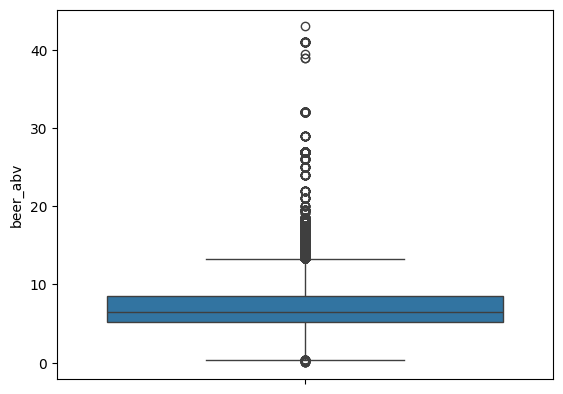

In [129]:
sns.boxplot(y = merged["beer_abv"])

### Identifying Outliers Using IQR

The Interquartile Range (IQR) method is used to calculate the number of outliers in the alcohol content column.

Insight:  
A small portion of beers have extreme ABV values compared to the majority.

In [130]:
import pandas as pd

col = merged["beer_abv"]

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = merged[(col < lower) | (col > upper)]

print("Number of outliers:", len(outliers))

Number of outliers: 12391


In [131]:
merged.head()


,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv
0,1,Sausa Weizen,stcules,1.5,NaN,NaN,NaN
1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2
2,3,BLACK HORSE BLACK BEER,stcules,3.0,NaN,NaN,NaN
3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0
4,5,Cauldron Dipa,johnmichaelsen,4.0,NaN,NaN,NaN


### Adding Detailed Review Scores

The dataset is further merged with detailed review attributes such as aroma, appearance, taste and palate scores using review_id.

Insight:  
This creates a comprehensive dataset containing both overall ratings and detailed sensory scores.

In [132]:
merged2= pd.merge(merged, review_details, on="review_id", how="left")

In [133]:
merged2.head()

,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv,aroma_score,appearance_score,taste_score,palate_score
0,1,Sausa Weizen,stcules,1.5,NaN,NaN,NaN,2.0,2.5,1.5,1.5
1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2,2.5,3.0,3.0,3.0
2,3,BLACK HORSE BLACK BEER,stcules,3.0,NaN,NaN,NaN,2.5,3.0,3.0,3.0
3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0,3.0,3.5,3.0,2.5
4,5,Cauldron Dipa,johnmichaelsen,4.0,NaN,NaN,NaN,4.5,4.0,4.5,4.0


In [134]:
merged2.isna().sum()

review_id                  0
beer_name                  0
reviewer_username        425
overall_score          98326
brewery_name          966336
beer_style            966334
beer_abv             1000301
aroma_score           145465
appearance_score           0
taste_score           135476
palate_score          231982
dtype: int64

In [135]:
df = merged2

### Handling Missing Values

Missing values are handled using different strategies:

• Missing brewery names are replaced with "Unknown"  
• Missing categorical values such as beer style are filled using the mode  
• Missing numerical values such as ABV are filled using the median

Insight:  
Handling missing values ensures the dataset remains complete and usable for analysis.

In [136]:
df["brewery_name"] = df["brewery_name"].fillna("Unknown")

In [137]:
df.isna().sum()

review_id                  0
beer_name                  0
reviewer_username        425
overall_score          98326
brewery_name               0
beer_style            966334
beer_abv             1000301
aroma_score           145465
appearance_score           0
taste_score           135476
palate_score          231982
dtype: int64

In [138]:
df["beer_style"] = df["beer_style"].fillna(df["beer_style"].mode()[0])

<Axes: >

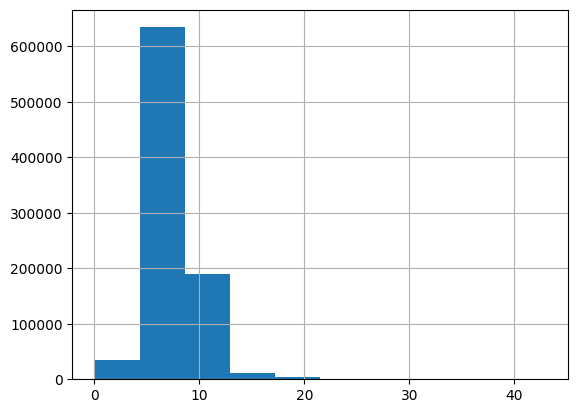

In [139]:
df["beer_abv"].hist()

In [140]:
df["beer_abv"] = df["beer_abv"].fillna(df["beer_abv"].median()) 

<Axes: >

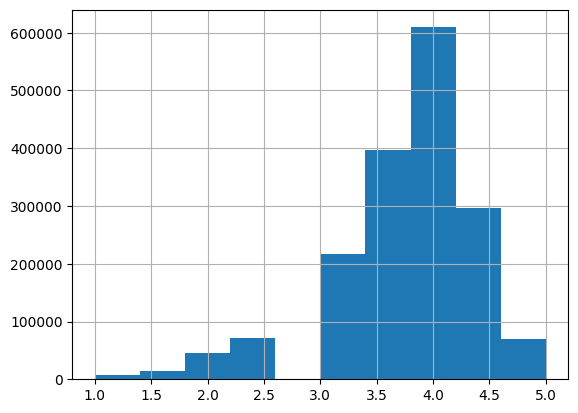

In [141]:
df["aroma_score"].hist()

In [142]:
df["aroma_score"] = df["aroma_score"].fillna(df["aroma_score"].median())


In [143]:
df["aroma_score"] = pd.to_numeric(df["aroma_score"], errors="coerce")

### Imputing Missing Rating Scores

An Iterative Imputer is used to estimate missing values for rating attributes such as aroma, taste, appearance and palate.

Insight:  
This method predicts missing values based on relationships between the rating attributes, preserving rating patterns.

In [144]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer()

cols = ["overall_score", "aroma_score", "taste_score", "palate_score", "appearance_score"]

df[cols] = imputer.fit_transform(df[cols])

In [145]:
df = df.dropna(subset=["reviewer_username"])

In [146]:
df.isna().sum()

review_id            0
beer_name            0
reviewer_username    0
overall_score        0
brewery_name         0
beer_style           0
beer_abv             0
aroma_score          0
appearance_score     0
taste_score          0
palate_score         0
dtype: int64

### Removing Duplicate Records

Duplicate entries are removed to ensure that each review is unique.

Insight:  
Removing duplicates improves the reliability and quality of the dataset.

In [147]:
df = df.drop_duplicates()

In [148]:
df.select_dtypes(include="object").columns

Index(['beer_name', 'reviewer_username', 'brewery_name', 'beer_style'], dtype='object')

In [149]:
df["beer_abv"] = pd.to_numeric(df["beer_abv"], errors="coerce")

In [150]:
df.shape

(1872069, 11)

### Final Clean Dataset

After merging datasets, handling missing values, and removing duplicates, the final cleaned dataset is created and saved for further analysis.

Insight:  
The cleaned dataset now contains complete beer review information and is ready for analysis.

In [152]:
df.shape

(1872069, 11)

## Objective 1: Identify the Best Performing Beer Styles

The goal of this objective is to identify which beer styles receive the highest average ratings from reviewers.

The dataset is grouped by beer style and the average rating, standard deviation, and number of reviews are calculated.

In [153]:
cols = ["beer_name", "reviewer_username", "brewery_name", "beer_style"]

for col in cols:
    df[col] = df[col].astype(str).str.lower().str.strip().str.replace(r"\s+", " ", regex=True)

In [154]:
df["beer_style"].nunique()

104

In [151]:
df.to_csv("beer.csv")

### Best Performing Beer Styles

Beer styles are ranked based on their average overall score while considering styles with a sufficient number of reviews.

Insight:  
Some beer styles consistently receive higher ratings, indicating strong popularity among reviewers.

In [155]:
style_stats = df.groupby("beer_style")["overall_score"].agg(["mean","std","count"])
#--------------------------------------------------------------------
style_stats = style_stats[style_stats["count"] >= 1000]
best_styles = style_stats.sort_values(
    by=["mean","std"],
    ascending=[False, True]
)

print(best_styles.head(10))

                                      mean       std  count
beer_style                                                 
american wild ale                 4.106377  0.640145  10138
gueuze                            4.099912  0.612816   3407
quadrupel (quad)                  4.073763  0.619037  10581
american double / imperial stout  4.040446  0.654755  30296
keller bier / zwickel bier        4.039050  0.617981   1277
russian imperial stout            4.030360  0.626294  32182
weizenbock                        4.023062  0.583948   5555
eisbock                           4.008306  0.612844   1561
american double / imperial ipa    3.998384  0.634415  49215
rye beer                          3.988733  0.589706   5605


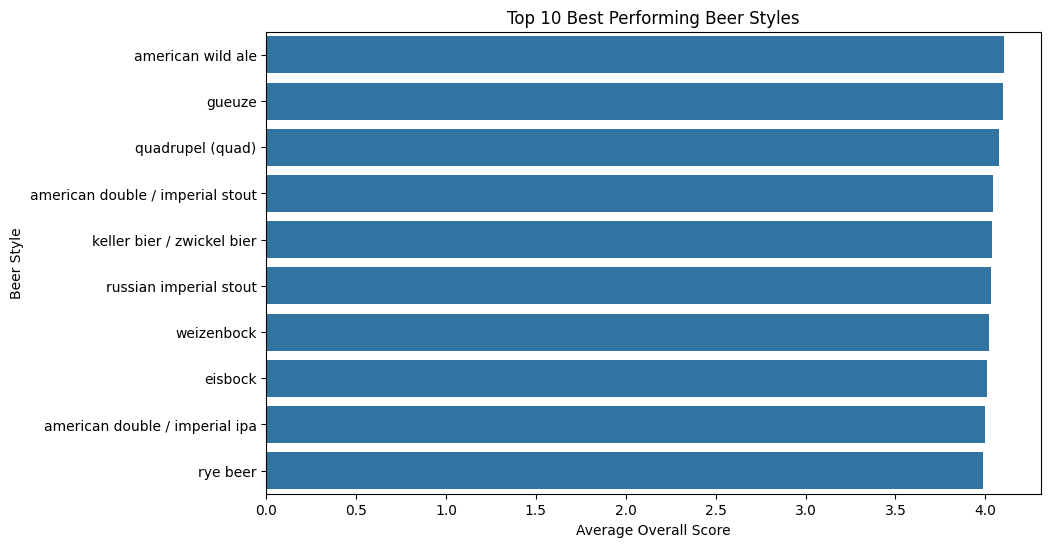

In [156]:
# get top 10 best styles
top10 = best_styles.head(10).reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="mean",
    y="beer_style"
)

plt.title("Top 10 Best Performing Beer Styles")
plt.xlabel("Average Overall Score")
plt.ylabel("Beer Style")

plt.show()

### Identifying Underperforming Beer Styles

Beer styles with average ratings below the global average are identified.

Insight:  
These styles receive lower ratings from reviewers and may indicate less preferred beer styles.

In [157]:
overall_mean = df["overall_score"].mean()
print(overall_mean)

3.8180389055661097


In [158]:
style_stats["difference_from_avg"] = style_stats["mean"] - overall_mean

In [159]:
underperforming = style_stats[style_stats["difference_from_avg"] < 0]

In [160]:
underperforming = underperforming[underperforming["count"] >= 1000]

In [161]:
underperforming.sort_values("difference_from_avg").head(10)

,mean,std,count,difference_from_avg
beer_style,,,,
american malt liquor,2.659264,1.024866,2148,-1.158775
light lager,2.666597,1.033940,7832,-1.151442
euro strong lager,2.935897,0.904210,1361,-0.882142
american adjunct lager,2.999071,0.927014,17370,-0.818968
chile beer,3.055293,1.131397,1127,-0.762746
japanese rice lager,3.124645,0.787493,1069,-0.693394
euro pale lager,3.229645,0.799807,9604,-0.588394
euro dark lager,3.408678,0.739324,2609,-0.409361
american pale lager,3.410136,0.812472,5082,-0.407903


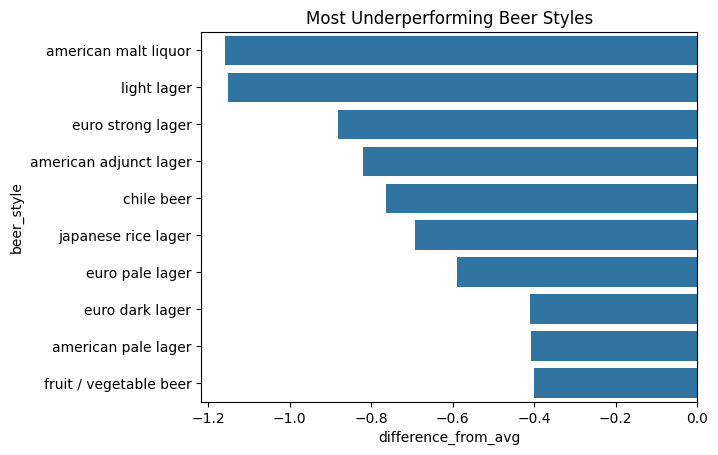

In [162]:
sns.barplot(
    data=underperforming.sort_values("difference_from_avg").head(10),
    x="difference_from_avg",
    y=underperforming.sort_values("difference_from_avg").head(10).index
)

plt.title("Most Underperforming Beer Styles")
plt.show()

## Conclusion – Objective 1

The analysis of beer styles based on overall review scores shows clear differences in reviewer preferences.  

Beer styles such as **American Wild Ale, Gueuze, Quadrupel, and American Double / Imperial Stout** received the highest average ratings, indicating that reviewers consistently rate these styles highly.

On the other hand, styles such as **American Malt Liquor, Light Lager, and Euro Strong Lager** received ratings significantly below the global average score.

Overall, the results suggest that strong, complex, and specialty beer styles tend to perform better among reviewers, while lighter or mass-market styles generally receive lower ratings.

## Objective 2: Determining Which Sensory Feature Influences Overall Rating

In this objective, we examine how different sensory attributes of beer — aroma, appearance, taste, and palate — relate to the overall rating given by reviewers.

These features represent the key aspects reviewers evaluate while tasting beer. By analyzing these attributes alongside the overall score, we aim to understand which sensory component contributes the most to a beer’s final rating.

In [163]:
features = ["aroma_score", "appearance_score", "taste_score", "palate_score"]
target = "overall_score"

In [164]:
corr = df[features + [target]].corr()

corr_with_target = corr[target].drop(target).sort_values(ascending=False)

print(corr_with_target)

taste_score         0.803796
palate_score        0.724984
aroma_score         0.630992
appearance_score    0.504775
Name: overall_score, dtype: float64


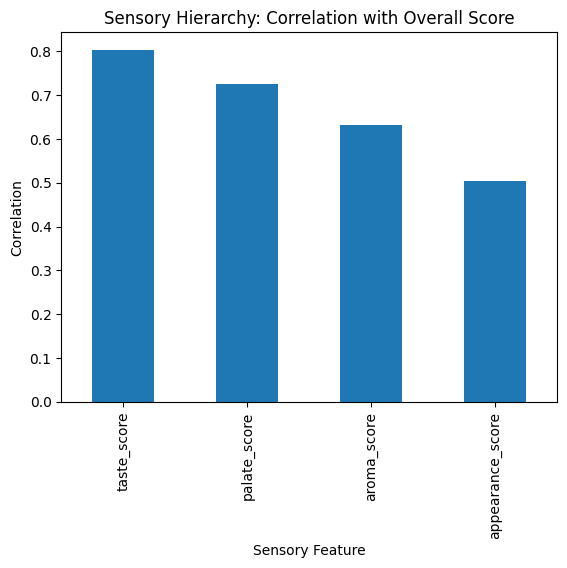

In [165]:
corr_with_target.plot(kind="bar")

plt.title("Sensory Hierarchy: Correlation with Overall Score")
plt.ylabel("Correlation")
plt.xlabel("Sensory Feature")

plt.show()

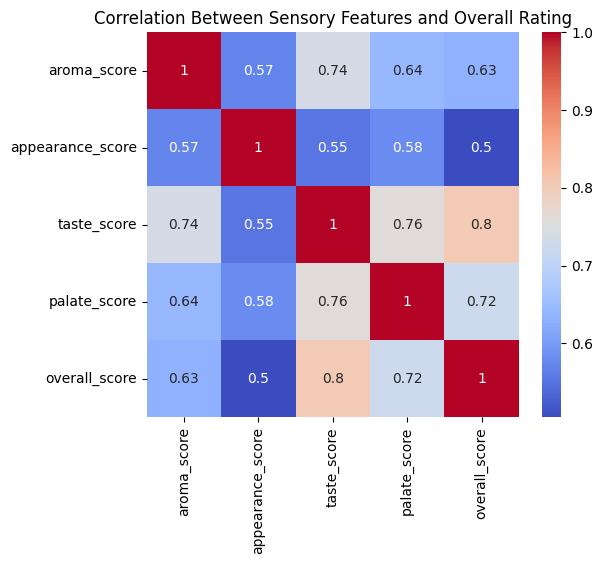

In [166]:
plt.figure(figsize=(6,5))

sns.heatmap(df[features + [target]].corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Between Sensory Features and Overall Rating")
plt.show()

## Objective 3: Comparing Brewery Size and Beer Ratings

This objective analyzes whether the popularity or size of a brewery influences the ratings its beers receive.

Brewery size is estimated using the number of reviews associated with each brewery. The assumption is that breweries with more reviews are likely larger or more popular among consumers.

In [167]:
df1 = df[df['brewery_name'] != 'unknown'].copy()

### Estimating Brewery Size

The number of reviews for each brewery is calculated. This review count is used as a proxy for brewery size or popularity.

Breweries are then categorized into three groups:

• Small breweries  
• Medium breweries  
• Large breweries

In [169]:
brewery_review_counts = df1.groupby('brewery_name')['overall_score'].count()

brewery_review_counts.head()


brewery_name
't hofbrouwerijke            7
(512) brewing company      141
10 barrel brewing co.       50
1516 brewing company         5
16 mile brewing company    278
Name: overall_score, dtype: int64

In [170]:
df1['brewery_review_count'] = df1['brewery_name'].map(brewery_review_counts)

df1.head()

,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv,aroma_score,appearance_score,taste_score,palate_score,brewery_review_count
1,2,red moon,stcules,3.0,vecchio birraio,english strong ale,6.2,2.5,3.0,3.000000,3.0,2
3,4,sausa pils,stcules,3.0,vecchio birraio,german pilsener,5.0,3.0,3.5,3.000000,2.5,2
5,6,caldera ginger beer,oline73,3.0,caldera brewing company,herbed / spiced beer,4.7,3.5,3.5,3.500000,3.0,600
7,8,caldera ginger beer,alpinebryant,3.0,caldera brewing company,herbed / spiced beer,4.7,2.5,3.5,3.500000,2.0,600
11,12,caldera ginger beer,madeinoregon,5.0,caldera brewing company,herbed / spiced beer,4.7,5.0,4.0,4.772171,4.0,600


In [171]:
def classify_brewery(size):
    if size > 5000:
        return "Large"
    elif size < 1000:
        return "Small"
    else:
        return "Medium"

df1['brewery_size'] = df1['brewery_review_count'].apply(classify_brewery)

df1['brewery_size'].value_counts()

brewery_size
Medium    331098
Large     315973
Small     258892
Name: count, dtype: int64

### Average Rating by Brewery Size

The average overall rating is calculated for each brewery size category to observe whether larger breweries receive better ratings.

Result from the data:

Large breweries → ~3.90 average rating  
Medium breweries → ~3.85 average rating  
Small breweries → ~3.69 average rating

This suggests that beers from larger breweries tend to receive slightly higher ratings on average.

In [172]:
df1.groupby('brewery_size')['overall_score'].mean()

brewery_size
Large     3.904505
Medium    3.857022
Small     3.692464
Name: overall_score, dtype: float64

### Distribution of Ratings by Brewery Size

A boxplot is used to visualize how beer ratings vary across small, medium, and large breweries.

Observation:

Ratings across all brewery sizes overlap significantly, but large breweries show slightly higher median ratings.

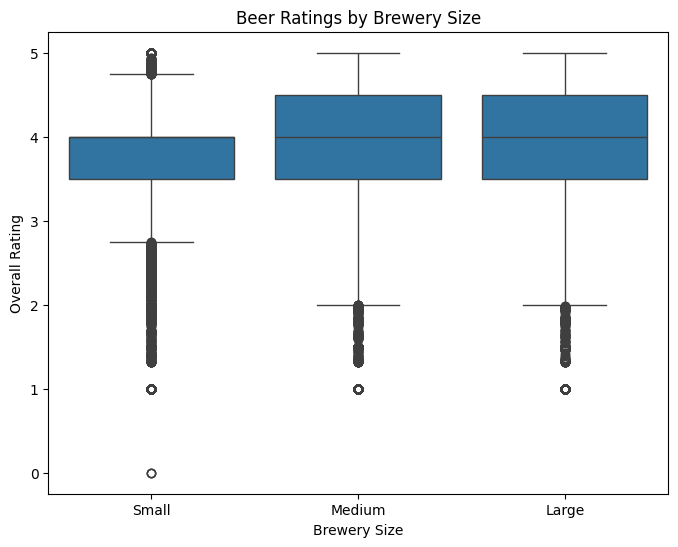

In [173]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(x='brewery_size', y='overall_score', data=df1)

plt.title("Beer Ratings by Brewery Size")
plt.xlabel("Brewery Size")
plt.ylabel("Overall Rating")

plt.show()

### Correlation Between Brewery Popularity and Ratings

The correlation between the number of brewery reviews and overall rating is calculated.

Result:  
Correlation ≈ **0.07**

This indicates a **very weak positive relationship** between brewery popularity and beer ratings.

In [174]:
df1[['brewery_review_count','overall_score']].corr()

,brewery_review_count,overall_score
brewery_review_count,1.000000,0.071358
overall_score,0.071358,1.000000


### Brewery Popularity vs Beer Rating

A scatter plot visualizes the relationship between the number of reviews a brewery receives and the ratings of its beers.

Observation:

The points are widely scattered with no strong upward or downward pattern, supporting the weak correlation result.

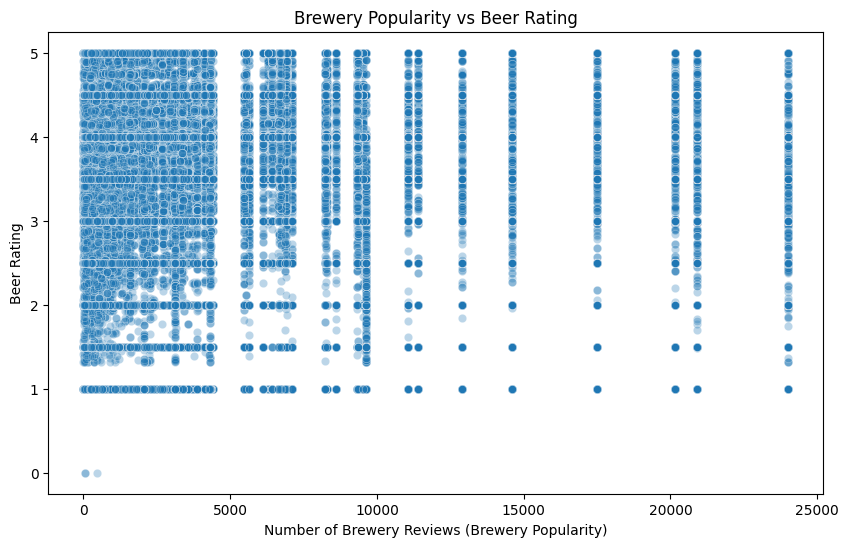

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='brewery_review_count',
    y='overall_score',
    data=df1,
    alpha=0.3
)

plt.title("Brewery Popularity vs Beer Rating")
plt.xlabel("Number of Brewery Reviews (Brewery Popularity)")
plt.ylabel("Beer Rating")

plt.show()

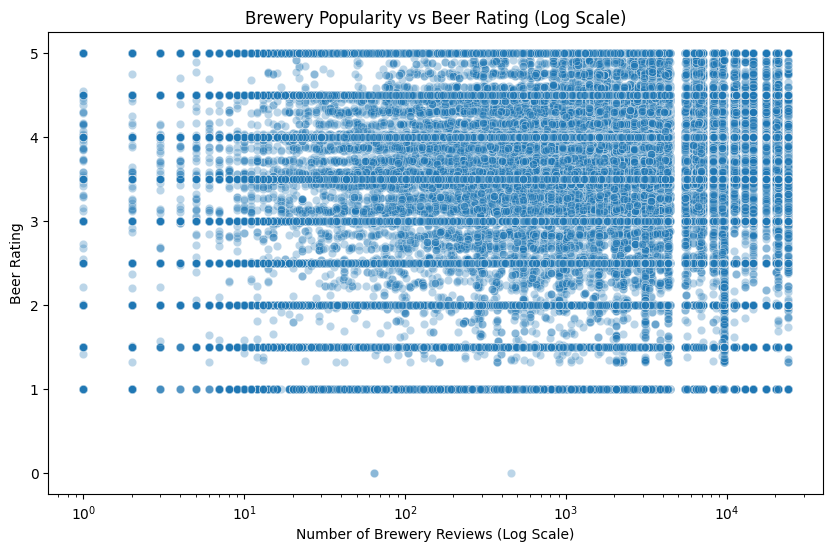

In [176]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='brewery_review_count',
    y='overall_score',
    data=df1,
    alpha=0.3
)

plt.xscale('log')

plt.title("Brewery Popularity vs Beer Rating (Log Scale)")
plt.xlabel("Number of Brewery Reviews (Log Scale)")
plt.ylabel("Beer Rating")

plt.show()

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    x='brewery_review_count',
    y='overall_score',
    data=df1,
    scatter_kws={'alpha':0.2},
    line_kws={'color':'red'}
)

plt.xscale('log')

plt.title("Relationship Between Brewery Popularity and Beer Rating")
plt.xlabel("Brewery Review Count (Log Scale)")
plt.ylabel("Beer Rating")

plt.show()

### Conclusion

The analysis shows that larger breweries tend to receive slightly higher average ratings compared to small breweries. However, the correlation between brewery popularity and beer rating is very weak.

This suggests that while larger breweries may have slightly better average ratings, the size or popularity of a brewery does not strongly determine the quality of its beers.

# Objective 4 — Reviewer Behavior Analysis

In this section, we analyze reviewer behavior in the beer review dataset. 
The goal is to understand whether certain reviewers show rating biases and whether experienced reviewers rate beers differently.

Key questions explored:
- Who are the most active reviewers?
- Do some reviewers consistently rate beers higher or lower than others?
- Does reviewer experience affect rating behavior?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Loding the cleaned dataset

In [ ]:
df4 = df.copy()


,Unnamed: 0,review_id,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv,aroma_score,appearance_score,taste_score,palate_score
0,0,1,Sausa Weizen,stcules,1.5,Unknown,AMERICAN IPA,6.5,2.0,2.5,1.5,1.5
1,1,2,Red Moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2,2.5,3.0,3.0,3.0
2,2,3,BLACK HORSE BLACK BEER,stcules,3.0,Unknown,AMERICAN IPA,6.5,2.5,3.0,3.0,3.0
3,3,4,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0,3.0,3.5,3.0,2.5
4,4,5,Cauldron Dipa,johnmichaelsen,4.0,Unknown,AMERICAN IPA,6.5,4.5,4.0,4.5,4.0


In [ ]:
df4.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1872069 entries, 0 to 1872068
Data columns (total 12 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Unnamed: 0         int64  
 1   review_id          int64  
 2   beer_name          object 
 3   reviewer_username  object 
 4   overall_score      float64
 5   brewery_name       object 
 6   beer_style         object 
 7   beer_abv           float64
 8   aroma_score        float64
 9   appearance_score   float64
 10  taste_score        float64
 11  palate_score       float64
dtypes: float64(6), int64(2), object(4)
memory usage: 171.4+ MB


In [ ]:
df4.columns

Index(['Unnamed: 0', 'review_id', 'beer_name', 'reviewer_username',
       'overall_score', 'brewery_name', 'beer_style', 'beer_abv',
       'aroma_score', 'appearance_score', 'taste_score', 'palate_score'],
      dtype='object')

Reviewer activity analysis
-Analyzing how many reviews each reviewer has left to idenfity most active reviewers

In [ ]:
review_counts=df4.groupby("reviewer_username").size()
review_counts=review_counts.sort_values(ascending=False)
review_counts.head(10)

reviewer_username
northyorksammy    6687
BuckeyeNation     5459
mikesgroove       5437
Thorpe429         4089
NeroFiddled       4058
ChainGangGuy      4043
womencantsail     4004
brentk56          3931
WesWes            3715
oberon            3712
dtype: int64

## Most Active Reviewers

The following chart shows the reviewers who have contributed the highest number of reviews.

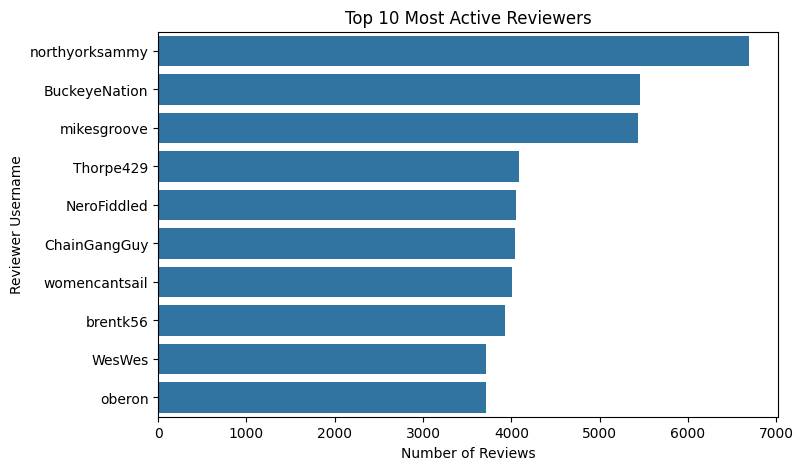

In [ ]:
top_reviewers = review_counts.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_reviewers.values,
    y=top_reviewers.index
)

plt.title("Top 10 Most Active Reviewers")
plt.xlabel("Number of Reviews")
plt.ylabel("Reviewer Username")

plt.show()

## Reviewer Bias Analysis

In this section, we analyze whether some reviewers consistently give higher or lower ratings than others.

We calculate:
- The average rating given by each reviewer
- The total number of reviews written

This helps identify generous reviewers and stricter critics.

In [ ]:
reviewer_stats = df4.groupby("reviewer_username")["overall_score"].agg(["mean", "count"])

reviewer_stats.head()


,mean,count
reviewer_username,,
0110x011,4.212985,167
01Ryan10,5.000000,1
02maxima,4.000000,4
03SVTCobra,3.000000,3
04101Brewer,4.166667,3


### Filtering Experienced Reviewers

Some reviewers have written only a few reviews, which may not represent reliable rating behavior.

To ensure meaningful analysis, we only consider reviewers who have written **at least 20 reviews**.

In [ ]:

reviewer_stats = reviewer_stats[reviewer_stats["count"] >= 20]

### Generous Reviewers

These reviewers tend to give higher ratings on average.

In [ ]:
reviewer_stats.sort_values("mean", ascending=False).head(10)

,mean,count
reviewer_username,,
oteyj,4.783538,107
Zippie9999,4.759794,28
Impfan,4.735409,29
FARGO619,4.734072,54
BeerLover48Fan,4.725124,48
paxtonthegreat,4.696429,28
mmthompson33,4.688878,42
xmorgan,4.668719,39
billzav,4.656648,30


### Strict Reviewers

These reviewers tend to give lower ratings and may have higher standards when evaluating beers.

In [ ]:
reviewer_stats.sort_values("mean").head(10)

,mean,count
reviewer_username,,
emiricius,2.380952,21
JBIII,2.418875,20
larrytm56,2.575000,20
cervezale,2.694172,33
palffyfan,2.738883,72
mcbiydw2,2.806502,20
JustLovinBeer,2.808783,47
Shearwater912,2.814815,27
anaduja,2.818492,32


### Reviewer Experience vs Rating Behavior

In this section, we examine whether reviewers who have written more reviews tend to give higher or lower ratings.

If experienced reviewers tend to give lower average ratings, it may suggest that they develop stricter standards over time.

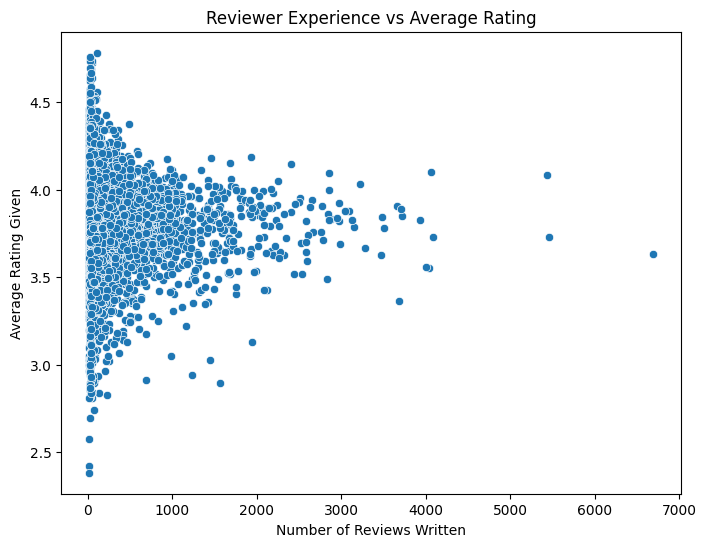

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=reviewer_stats["count"],
    y=reviewer_stats["mean"]
)

plt.xlabel("Number of Reviews Written")
plt.ylabel("Average Rating Given")
plt.title("Reviewer Experience vs Average Rating")

plt.show()

### Insight from Reviewer Experience vs Rating

The scatter plot shows the relationship between reviewer experience and the average rating they give.

Most reviewers in the dataset write fewer than 100 reviews, indicating that the majority of users are casual reviewers. Only a small group of reviewers contributes a large number of reviews.

Average ratings generally fall between 3.5 and 4.2, suggesting that reviewers tend to rate beers positively overall.

Reviewers with a large number of reviews tend to give more moderate ratings, indicating that experienced reviewers may develop stricter or more balanced evaluation standards over time.

### Reviewer Consistency

We measure how consistent reviewers are in their rating behavior by calculating the standard deviation of the ratings they give.

- A **low standard deviation** means the reviewer gives similar ratings most of the time (consistent).
- A **high standard deviation** means the reviewer gives very different ratings across beers (less consistent).

In [ ]:
reviewer_consistency = df4.groupby("reviewer_username")["overall_score"].std()
reviewer_consistency = reviewer_consistency.loc[reviewer_stats.index]
reviewer_consistency.head()

reviewer_username
0110x011       0.690158
05Harley       0.418198
0tt0           0.843389
1000Bottles    0.719162
100floods      0.682395
Name: overall_score, dtype: float64

In [ ]:
reviewer_consistency.sort_values().head(10)

reviewer_username
B0bD0bbselbock      0.190347
wscaffe             0.241523
SABERG              0.248093
ngeunit1            0.250610
stone3187           0.270677
HopHeadJim          0.273548
Wackyfoot           0.274395
hippityhophead24    0.277958
Agent1              0.283265
GeorgeAldi          0.283818
Name: overall_score, dtype: float64

In [ ]:
reviewer_consistency.sort_values(ascending=False).head(10)

reviewer_username
GeoJ               1.815190
dog                1.624928
jellis00           1.621854
Shearwater912      1.563700
NascarJDS          1.524034
Surefire           1.496651
XxBeerIsBestxX     1.486671
EddieTheTrooper    1.474557
Bricelyn           1.469781
glamphetamine      1.436762
Name: overall_score, dtype: float64

### Reviewer Consistency Analysis

Reviewer consistency was measured using the standard deviation of ratings given by each reviewer.

Reviewers such as **cpmichael**, **BWMKappaSig**, and **sraimondi** show very low standard deviation values, indicating highly consistent rating behavior. These reviewers tend to give ratings that remain close to their average.

In contrast, reviewers like **KyleVick4**, **Weizenmensch**, and **davod23** have much higher standard deviation values, meaning their ratings vary widely across different beers.

This suggests that while some reviewers follow a stable evaluation pattern, others display more variability in their scoring, reflecting different reviewing styles and preferences.

### Distribution of Overall Ratings

We examine the distribution of overall beer ratings to understand how reviewers generally rate beers in the dataset.

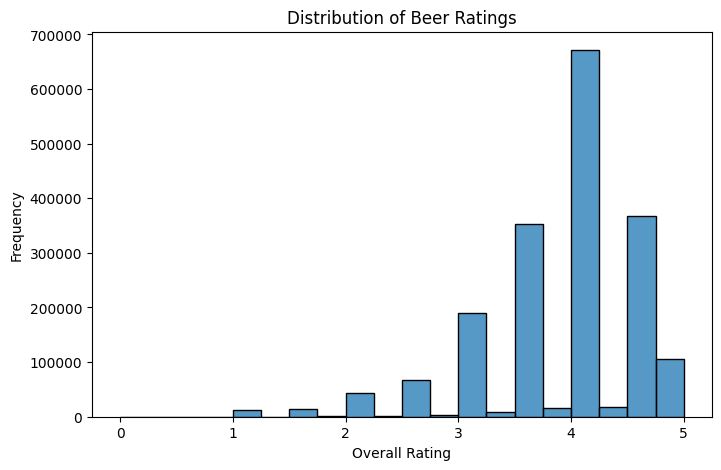

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["overall_score"], bins=20)

plt.title("Distribution of Beer Ratings")
plt.xlabel("Overall Rating")
plt.ylabel("Frequency")

plt.show()

### Distribution of Beer Ratings

The histogram shows that most beer ratings fall between **3.5 and 4.5**, with a strong concentration around **4.0–4.3**. This indicates that reviewers generally rate beers positively.

Very low ratings are relatively rare, suggesting that reviewers may be more likely to review beers they enjoy or that the reviewing community tends to evaluate beers favorably.

Although some beers receive ratings close to **5.0**, these occur less frequently, indicating that reviewers reserve the highest ratings for exceptional beers.

Overall, the distribution suggests a positive bias in beer ratings, with most reviews reflecting favorable opinions.

## Objective 5: Predicting Beer Ratings Using Machine Learning

In this objective, we build a machine learning model to predict the **overall beer rating** using sensory attributes and alcohol content.

The features used for prediction are:
- Aroma score
- Taste score
- Palate score
- Appearance score
- Alcohol by volume (ABV)

The target variable is the **overall_score**, which represents the final rating given by reviewers.

In [ ]:
X = df[
    ["aroma_score", "taste_score", "palate_score",
     "appearance_score", "beer_abv"]]
y = df["overall_score"]

### Splitting the Dataset

The dataset is divided into **training and testing sets** to evaluate the performance of the prediction model.

- **80% of the data** is used for training the model.
- **20% of the data** is used for testing.

This ensures that the model is evaluated on unseen data, providing a more reliable measure of prediction performance.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_train.dtypes)

aroma_score         float64
taste_score         float64
palate_score        float64
appearance_score    float64
beer_abv            float64
dtype: object


### Training the Prediction Model

An **XGBoost Regressor** model is used to predict beer ratings.  
XGBoost is a powerful gradient boosting algorithm that performs well for structured tabular datasets.

The model is trained using the sensory features and alcohol content to learn how these characteristics influence the final beer rating.

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False)

print(importance)

taste_score         0.896189
palate_score        0.060445
appearance_score    0.016274
aroma_score         0.013844
beer_abv            0.013249
dtype: float32


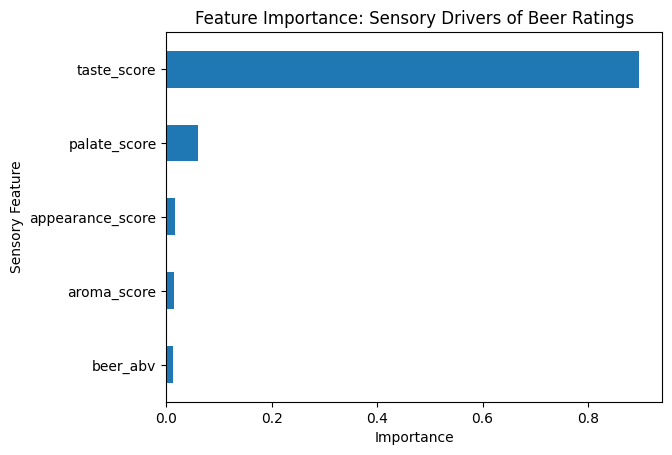

In [ ]:

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance: Sensory Drivers of Beer Ratings")
plt.xlabel("Importance")
plt.ylabel("Sensory Feature")

plt.show()

### Model Performance Evaluation

The performance of the model is evaluated using three metrics:

- **R² Score** – measures how well the model explains the variance in ratings.
- **RMSE (Root Mean Squared Error)** – measures prediction error magnitude.
- **MAE (Mean Absolute Error)** – measures the average absolute difference between predicted and actual ratings.

Results:

- **R² Score ≈ 0.74**, indicating the model explains about 74% of the variation in beer ratings.
- The relatively low RMSE and MAE values suggest that the model predictions are reasonably accurate.

This shows that sensory attributes are strong predictors of overall beer ratings.

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error


y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.7385503741632538
RMSE: 0.3646884787650759
MAE: 0.25743770251778714


### Sensory Profile of Top-Rated Beers

To understand what characterizes highly rated beers, we analyze beers with an **overall score of 4.5 or higher**.

The average sensory scores of these top-rated beers show:

- **Taste score is the highest**
- Palate and aroma also score highly
- Appearance is slightly lower but still strong

This suggests that beers receiving the highest ratings typically excel in **taste and palate quality**, reinforcing the importance of flavor experience in reviewer evaluations.

In [ ]:
top_beers = df[df["overall_score"] >= 4.5]

top_profile = top_beers[
    ["aroma_score","taste_score","palate_score","appearance_score"]
].mean()

top_profile

aroma_score         4.171858
taste_score         4.375748
palate_score        4.241841
appearance_score    4.165567
dtype: float64

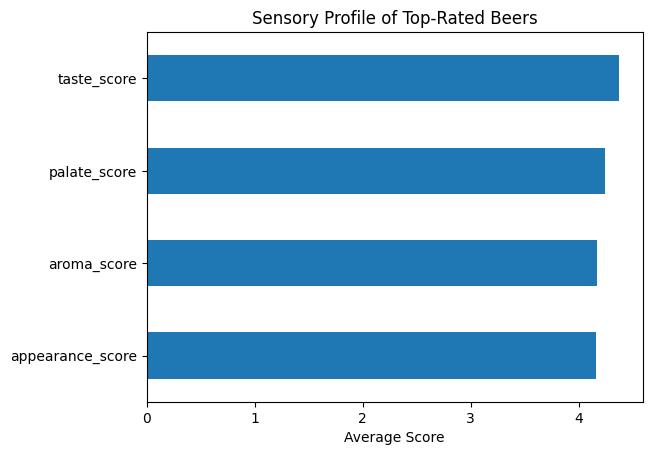

In [ ]:
top_profile.sort_values().plot(kind="barh")

plt.title("Sensory Profile of Top-Rated Beers")
plt.xlabel("Average Score")
plt.show()

## Final Conclusion

This project analyzed a large beer review dataset to understand the factors influencing beer ratings and reviewer behavior.

The analysis showed that **sensory attributes play a major role in determining beer ratings**, with **taste and palate scores being the strongest contributors** to the overall score. Breweries with more reviews tend to have slightly higher average ratings, but the relationship between brewery popularity and rating is relatively weak.

Reviewer behavior analysis revealed that **a small group of highly active reviewers contribute a large portion of the reviews**, while most users write only a few. Experienced reviewers tend to give slightly more moderate ratings, suggesting that familiarity with different beers may lead to more balanced evaluations.

The machine learning model further confirmed that **taste is the most influential feature in predicting beer ratings**, followed by palate. The model achieved a reasonably strong predictive performance, showing that sensory characteristics can effectively explain a large portion of the variation in overall ratings.

Overall, the study highlights that **flavor-related attributes and reviewer experience are key factors shaping beer evaluation patterns in the dataset.**

# Objective 6

## Objective 6 — Beer Similarity and Recommendation System

In this section, we build a **beer recommendation system** based on the similarity of sensory characteristics.  
The goal is to recommend beers that have similar flavor profiles based on attributes such as aroma, taste, palate, appearance, and alcohol content.

We use the following steps:
- Aggregate review data to create a profile for each beer.
- Filter beers with sufficient review counts for reliability.
- Normalize features for fair comparison.
- Compute similarity between beers using cosine similarity.
- Recommend beers similar to a given beer.

In [ ]:
# Aggregate beer profiles from review data
beer_profiles = df.groupby(["beer_name", "beer_style", "beer_abv"]).agg(
    overall_score=("overall_score", "mean"),
    aroma_score=("aroma_score", "mean"),
    taste_score=("taste_score", "mean"),
    palate_score=("palate_score", "mean"),
    appearance_score=("appearance_score", "mean"),
    review_count=("overall_score", "count")
).reset_index()

# Keep beers with at least 10 reviews for reliability
beer_profiles = beer_profiles[beer_profiles["review_count"] >= 10].reset_index(drop=True)
print(f"Beer profiles: {len(beer_profiles)}")


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

feature_cols = ["aroma_score", "taste_score", "palate_score", "appearance_score", "beer_abv"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(beer_profiles[feature_cols].fillna(0))

# Compute cosine similarity matrix
similarity_matrix = cosine_similarity(X_scaled)
print(f"Similarity matrix shape: {similarity_matrix.shape}")


In [ ]:
recommend_beers("guinness draught")

239507                      Blackout Stout 
256837     GRITTY MCDUFF'S BLACK FLY STOUT 
256838    GRITTY MCDUFF'S BLACK FLY STOUT  
25035                          IRISH STOUT 
30490                  MAXWELL'S DRY STOUT 
Name: beer_name, dtype: object

In [ ]:
recommend_beers("guinness")

,beer_name,beer_style,beer_abv,overall_score
3752,peak organic amber ale,american amber / red ale,5.904412,3.609296
510,belhaven best,american ipa,4.929167,3.532735
3250,moling's traditional red ale,american ipa,5.374419,3.564448
5635,young's winter warmer,winter warmer,5.695565,3.629495
4410,schöfferhofer hefeweizen,hefeweizen,5.710526,3.641774


##### Above are the results from the model which recommend similar beer styles